In [ ]:
import pandas as pd
df = pd.read_csv("/spam.csv", encoding='latin-1')
df.head()
df.shape
df.columns.tolist()




['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

In [ ]:
df['v1'].value_counts()

,count
v1,
ham,4825
spam,747


In [ ]:
print("Spam examples:")
print(df[df['v1'] == 'spam'].head(3)[['v1', 'v2']])

print("\nHam examples:")
print(df[df['v1'] == 'ham'].head(3)[['v1', 'v2']])


Spam examples:
     v1                                                 v2
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
5  spam  FreeMsg Hey there darling it's been 3 week's n...
8  spam  WINNER!! As a valued network customer you have...

Ham examples:
    v1                                                 v2
0  ham  Go until jurong point, crazy.. Available only ...
1  ham                      Ok lar... Joking wif u oni...
3  ham  U dun say so early hor... U c already then say...


In [ ]:
spam_count = df['v1'].value_counts()['spam']
total_count = len(df)
spam_percentage = (spam_count / total_count) * 100
print(f"Percentage of spam messages: {spam_percentage:.2f}%")


Percentage of spam messages: 13.41%


In [ ]:
spam_count = df['v1'].value_counts()['spam']
ham_count = df['v1'].value_counts()['ham']
total_count = len(df)

P_spam = spam_count / total_count
P_ham = ham_count / total_count

print(f"P(spam) = {P_spam:.4f}")
print(f"P(ham) = {P_ham:.4f}")


P(spam) = 0.1341
P(ham) = 0.8659


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df,
                                     test_size = 0.2,
                                     random_state = 42)


In [ ]:
spam_train = train_df[train_df['v1'] == 'spam']
ham_train = train_df[train_df['v1'] == 'ham']

free_in_spam = spam_train['v2'].str.contains('free', case=False, na=False).sum()
free_in_ham = ham_train['v2'].str.contains('free', case=False, na=False).sum()

print(f"'free' appears in {free_in_spam} spam messages")
print(f"'free' appears in {free_in_ham} ham messages")



'free' appears in 164 spam messages
'free' appears in 54 ham messages


In [ ]:
P_free_given_spam = free_in_spam / len(spam_train)
P_free_given_ham = free_in_ham / len(ham_train)

print(f"P('free'|spam) = {P_free_given_spam:.4f}")
print(f"P('free'|ham) = {P_free_given_ham:.4f}")


P('free'|spam) = 0.2747
P('free'|ham) = 0.0140


In [ ]:
if P_free_given_spam > P_free_given_ham:
    print("Message containing 'free' is more likely spam.")
else:
    print("Message containing 'free' is more likely ham.")


Message containing 'free' is more likely spam.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer
vectorizer = CountVectorizer()

# Fit on training text and transform both train and test
X_train = vectorizer.fit_transform(train_df['v2'])
X_test  = vectorizer.transform(test_df['v2'])
y_train = train_df['v1']
y_test  = test_df['v1']


In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Initialize and train
nb = MultinomialNB()
nb.fit(X_train, y_train)


MultinomialNB()

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = nb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy: {accuracy:.4f}")



Model accuracy: 0.9839


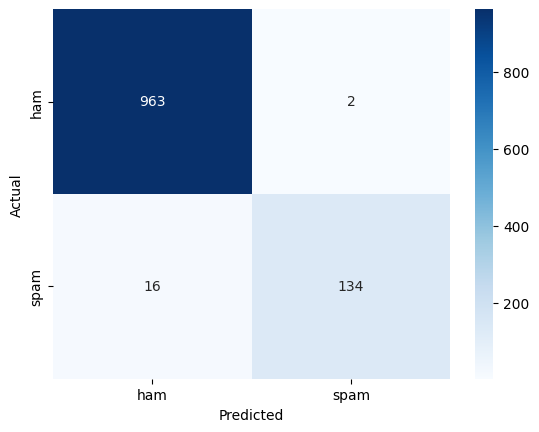

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=['ham','spam'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
feature_names = vectorizer.get_feature_names_out()


In [ ]:
import numpy as np

# Get log probabilities for both classes from the trained model
log_prob_spam = nb.feature_log_prob_[1]
log_prob_ham = nb.feature_log_prob_[0]

# Calculate probability ratios (spam vs ham)
prob_ratios = np.exp(log_prob_spam) / np.exp(log_prob_ham)

# Sort indices of top words with highest ratios
top_indices = np.argsort(prob_ratios)[-5:][::-1]

# Top indicative words
top_words = feature_names[top_indices]
print("Top 5 words strongest for spam:")
for word in top_words:
    print(word)


Top 5 words strongest for spam:
claim
prize
uk
150p
tone


In [ ]:
custom_msg = ["Free call now! Win money!"]
custom_msg_vec = vectorizer.transform(custom_msg)
prediction = nb.predict(custom_msg_vec)[0]
print(f"Custom message classified as: {prediction}")


Custom message classified as: spam


In [ ]:
msg1 = ["Call me"]
msg2 = ["Free call"]
prob_msg1 = nb.predict_proba(vectorizer.transform(msg1))
prob_msg2 = nb.predict_proba(vectorizer.transform(msg2))

print(f"Probability scores for '{msg1[0]}': {prob_msg1}")
print(f"Probability scores for '{msg2[0]}': {prob_msg2}")


Probability scores for 'Call me': [[0.94777563 0.05222437]]
Probability scores for 'Free call': [[0.14643336 0.85356664]]
